# 🎯 Medidas de Dispersão

Ao final, você deve conseguir:

* Entender o que é dispersão na prática
* Identificar quando usar cada medida
* Aplicar em dados reais (ex: custos, tempo de espera, produção médica)
* Interpretar resultados para tomada de decisão

#🧸  Exemplo conceitual inicial

Imagine dois cenários:

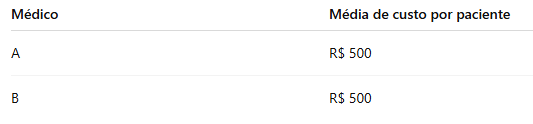

Mesma média. Mas:
* Médico A: todos pacientes entre 480–520
* Médico B: pacientes entre 100–2000

👉 A média é igual, mas o comportamento é completamente diferente.

➡️ É aqui que entram as medidas de dispersão.

# 📊 Conceito de Amplitude

Diferença entre o maior e o menor valor. Mede o “tamanho total do intervalo”. Muito sensível a outliers.

In [1]:
import pandas as pd

dados = pd.Series([100, 200, 300, 400, 2000])

amplitude = dados.max() - dados.min()
print(amplitude)

1900


Interpretação (saúde)
* Alta amplitude → grande variação de custos/procedimentos

Pode indicar:
* heterogeneidade clínica
* problema de padronização
* outliers importantes

# 📊 Conceito de Intervalo Interquartil (IQR)

Foca nos 50% centrais dos dados

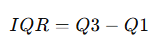

Interpretação (saúde)
* Ignora extremos
* Muito mais robusto que a amplitude

In [2]:
q1 = dados.quantile(0.25)
q3 = dados.quantile(0.75)
iqr = q3 - q1

print(q1, q3, iqr)

200.0 400.0 200.0


Pode indicar:
* IQR alto → variabilidade na “parte normal” dos dados
* IQR baixo → dados mais consistentes

# 📊 Conceito de Curtose (Kurtosis)

A curtose é uma medida que descreve o grau de achatamento da distribuição e a forma das caudas de uma distribuição em relação a uma distribuição normal. Em termos práticos, a curtose indica o quão concentrados estão os dados em torno da média e o quanto eles se espalham para valores extremos.


Tipos:
* Leptocúrtica → muitos extremos
* Mesocúrtica → normal
* Platicúrtica → mais achatada

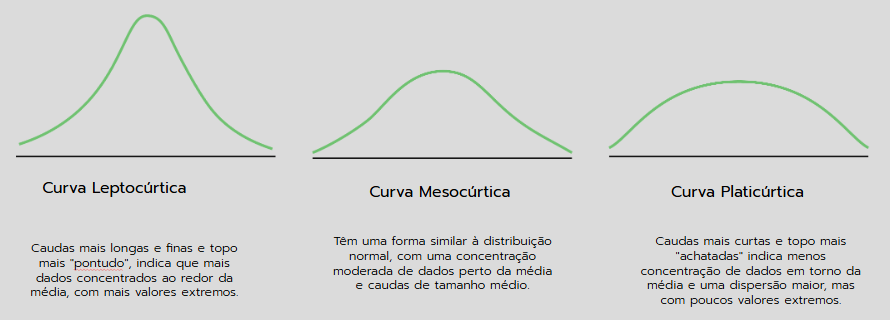

In [3]:
curtose = dados.kurtosis()
print(curtose)

4.60608


👉 Interpretação

Alta curtose → risco de eventos extremos (ex: pacientes de alto custo)

Baixa curtose → comportamento mais estável

# 🧪 Dataset aplicado

In [5]:
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "paciente_id": range(1, 101),
    "custo_internacao": np.random.gamma(shape=2, scale=500, size=100)
})

In [6]:
resumo = {
    "min": df["custo_internacao"].min(),
    "max": df["custo_internacao"].max(),
    "amplitude": df["custo_internacao"].max() - df["custo_internacao"].min(),
    "q1": df["custo_internacao"].quantile(0.25),
    "q3": df["custo_internacao"].quantile(0.75),
    "iqr": df["custo_internacao"].quantile(0.75) - df["custo_internacao"].quantile(0.25),
    "variancia": df["custo_internacao"].var(),
    "desvio_padrao": df["custo_internacao"].std(),
    "curtose": df["custo_internacao"].kurtosis()
}

for k, v in resumo.items():
    print(f"{k}: {round(v,2)}")

min: 107.05
max: 3649.0
amplitude: 3541.95
q1: 544.45
q3: 1202.05
iqr: 657.6
variancia: 376012.75
desvio_padrao: 613.2
curtose: 3.28


Cenário real. Se você vê:
* Amplitude alta
* IQR moderado
* Curtose alta

👉 Interpretação:
A maioria dos pacientes é homogênea. Mas existem poucos casos MUITO caros

➡️ Isso é clássico em:
* pacientes crônicos complexos
* internações evitáveis
* eventos adversos

# 🔥 Takeaway

* Média sozinha engana
* Dispersão mostra risco e variabilidade
* IQR é mais confiável que amplitude
* Desvio padrão é o padrão do mercado
* Curtose revela eventos extremos